<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/chapter10_interpreting_what_convnets_learn_compact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
"""
ConvNet이 무엇을 학습했는지 해석하는 3가지 핵심 기법
(원본 노트북의 멀티 백엔드/Colab 업로드 등 부가 코드는 제거하고,
 사전학습 VGG16 하나로 핵심 아이디어만 재현)

1. 중간 활성화 시각화  - 특정 conv층이 이미지의 어디에 반응하는지 확인
2. 필터 패턴 시각화     - 경사상승법으로 필터를 최대로 활성화하는 입력 이미지 생성
3. Grad-CAM 히트맵      - 예측에 가장 크게 기여한 영역을 이미지 위에 표시
"""

import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── 사전학습 모델 & 예시 이미지 준비 ─────────────────────────────
model = keras.applications.vgg16.VGG16(weights="imagenet")

img_path = keras.utils.get_file(
    fname="cat.jpg", origin="https://img-datasets.s3.amazonaws.com/cat.jpg"
)

def load_image(path, size):
    img = keras.utils.load_img(path, target_size=size)
    return np.expand_dims(keras.utils.img_to_array(img), axis=0)

img_array = load_image(img_path, (224, 224))


In [6]:
img_array.shape # (배치 크기, 세로, 가로, 채널)

(1, 224, 224, 3)

In [10]:
img_array[0].shape

(224, 224, 3)

In [5]:
print(img_array[0])

[[[  3.   3.   5.]
  [  7.   7.   9.]
  [  7.   9.   8.]
  ...
  [  2.   3.   8.]
  [  1.   2.   7.]
  [  0.   0.   5.]]

 [[  9.   9.  11.]
  [  6.   6.   8.]
  [  6.   8.   7.]
  ...
  [  2.   3.   8.]
  [  1.   2.   7.]
  [  1.   2.   7.]]

 [[  8.   8.   8.]
  [  8.   8.   8.]
  [  8.  10.   9.]
  ...
  [  1.   2.   7.]
  [  3.   2.   8.]
  [  3.   2.   8.]]

 ...

 [[150. 148.  71.]
  [166. 165.  85.]
  [120. 117.  38.]
  ...
  [ 94.  92.  33.]
  [ 92.  90.  33.]
  [ 97.  95.  38.]]

 [[157. 158.  78.]
  [125. 126.  48.]
  [137. 135.  61.]
  ...
  [ 82.  81.  24.]
  [ 92.  91.  34.]
  [ 92.  91.  34.]]

 [[145. 147.  64.]
  [150. 151.  73.]
  [166. 164.  90.]
  ...
  [ 87.  86.  30.]
  [ 94.  93.  37.]
  [ 80.  81.  24.]]]


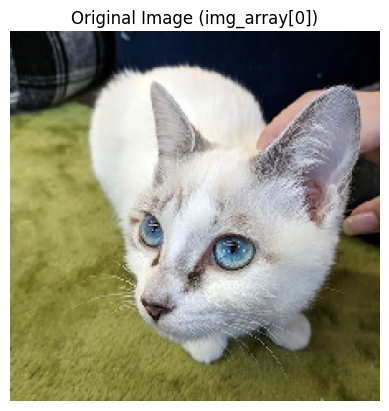

In [18]:
plt.imshow(img_array[0].astype('uint8'))
plt.axis('off')
plt.title('Original Image (img_array[0])')
plt.show()

In [12]:
preprocessed = keras.applications.vgg16.preprocess_input(img_array.copy())

In [21]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

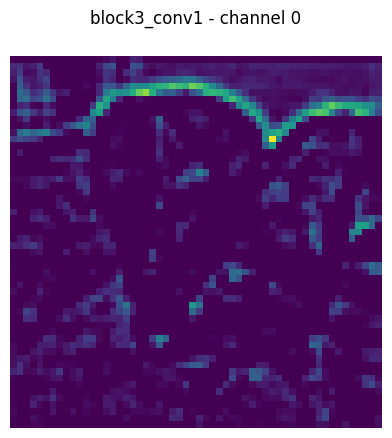

In [14]:
# ── 1. 중간 활성화 시각화 ────────────────────────────────────────
def show_intermediate_activation(layer_name="block3_conv1", channel=0):
    layer_output = model.get_layer(layer_name).output
    activation_model = keras.Model(model.input, layer_output)
    activation = activation_model.predict(preprocessed, verbose=0)

    plt.matshow(activation[0, :, :, channel], cmap="viridis")
    plt.title(f"{layer_name} - channel {channel}")
    plt.axis("off")
    # plt.savefig("1_intermediate_activation.png", bbox_inches="tight")
    plt.show()
    plt.close()

show_intermediate_activation()

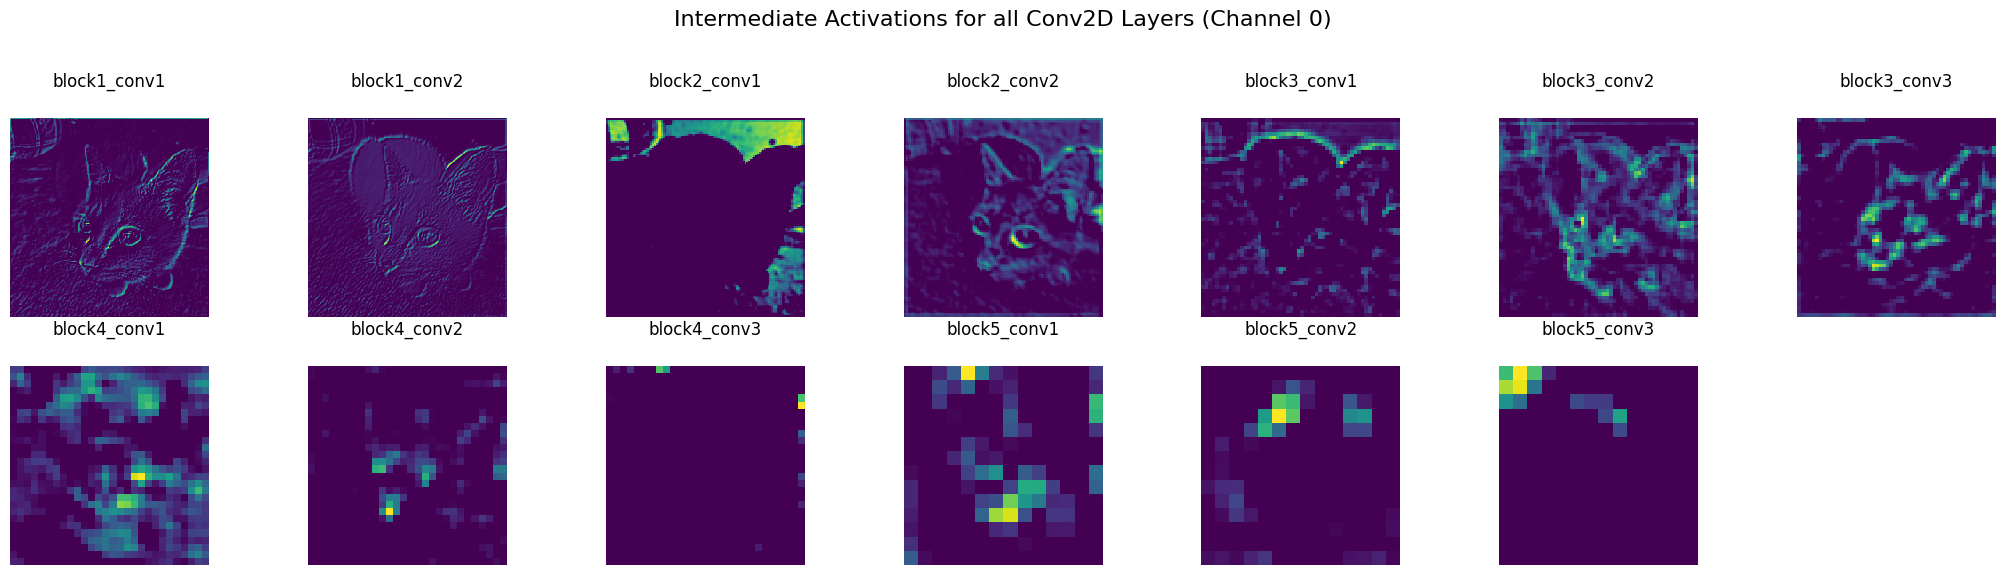

In [23]:
import math

# Get all Conv2D layers from the model
conv_layers = [layer for layer in model.layers if isinstance(layer, keras.layers.Conv2D)]

if not conv_layers:
    print("No Conv2D layers found in the model.")
else:
    num_layers = len(conv_layers)
    num_cols = 7
    num_rows = math.ceil(num_layers / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))
    # Flatten axes array for easy iteration if it's a multi-row grid
    if num_rows > 1:
        axes = axes.flatten()
    else: # Handle case with a single row where axes is 1D
        axes = [axes]

    fig.suptitle('Intermediate Activations for all Conv2D Layers (Channel 0)', fontsize=16)

    for i, layer in enumerate(conv_layers):
        ax = axes[i]
        layer_output = model.get_layer(layer.name).output
        activation_model = keras.Model(model.input, layer_output)
        activation = activation_model.predict(preprocessed, verbose=0)

        # Check if activation has at least one channel to display
        if activation.ndim == 4 and activation.shape[-1] > 0:
            ax.matshow(activation[0, :, :, 0], cmap='viridis')
            ax.set_title(f'{layer.name}')
            ax.axis('off')
        else:
            ax.set_title(f'{layer.name}\n(No visual output)')
            ax.axis('off')

    # Hide any unused subplots
    for j in range(num_layers, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

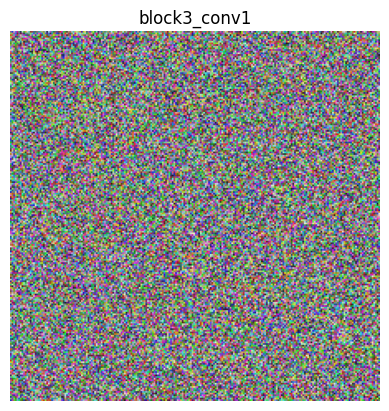

In [20]:
# ── 2. 필터 패턴 시각화 (경사상승법) ─────────────────────────────
def generate_filter_pattern(layer_name, filter_index, size=224, steps=30, lr=10.0):
    feature_extractor = keras.Model(model.input, model.get_layer(layer_name).output)

    image = tf.random.uniform((1, size, size, 3), minval=0.4, maxval=0.6)
    for _ in range(steps):
        with tf.GradientTape() as tape:
            tape.watch(image)
            activation = feature_extractor(image)
            # 가장자리를 제외한 영역의 필터 활성도 평균 = 손실
            loss = tf.reduce_mean(activation[:, 2:-2, 2:-2, filter_index])
        grads = tape.gradient(loss, image)
        grads /= tf.sqrt(tf.reduce_mean(grads ** 2)) + 1e-8  # 그래디언트 정규화
        image += lr * grads  # 손실이 커지는 방향으로 이미지 갱신

    img = image[0].numpy()
    img = (img - img.mean()) / (img.std() + 1e-8)
    return np.clip(img * 64 + 128, 0, 255).astype("uint8")

pattern = generate_filter_pattern("block3_conv1", filter_index=0)
plt.imshow(pattern)
plt.axis("off")
# plt.savefig("2_filter_pattern.png", bbox_inches="tight")
plt.axis('off')
plt.title('block3_conv1')
plt.show()
plt.close()

Grad-CAM(Gradient-weighted Class Activation Mapping) 기법을 구현한 코드로, 모델이 이미지의 어느 부위를 보고 최종 판단(클래스 분류)을 내렸는지 열지도(Heatmap) 형태로 시각화하는 역할

빨간색/노란색 영역은 모델이 판단에 결정적으로 참고한 중요 부위이며, 푸른색 영역은 무시한 부위

/tmp/ipykernel_2085/2976875328.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet_colors = cm.get_cmap("jet")(np.arange(256))[:, :3]


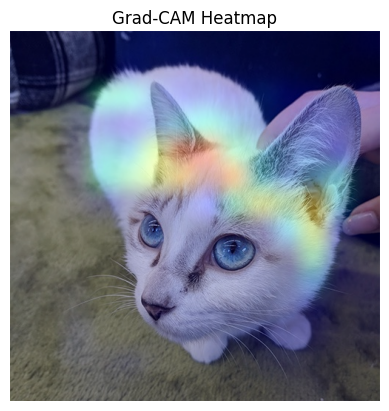

완료 → 1_intermediate_activation.png, 2_filter_pattern.png, 3_gradcam.png


In [19]:
# ── 3. Grad-CAM 히트맵 ───────────────────────────────────────────
def make_gradcam_heatmap(last_conv_layer_name):
    grad_model = keras.Model(
        model.input,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(preprocessed)
        top_class_channel = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(top_class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # 채널별 중요도

    conv_output = conv_output[0].numpy()
    for i in range(pooled_grads.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]

    heatmap = np.maximum(np.mean(conv_output, axis=-1), 0)  # ReLU
    return heatmap / (heatmap.max() + 1e-8)

heatmap = make_gradcam_heatmap("block5_conv3")

original = keras.utils.img_to_array(keras.utils.load_img(img_path))
heatmap_uint8 = np.uint8(255 * heatmap)
jet_colors = cm.get_cmap("jet")(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_uint8]
jet_heatmap = keras.utils.array_to_img(jet_heatmap).resize(
    (original.shape[1], original.shape[0])
)

jet_heatmap = keras.utils.img_to_array(jet_heatmap)

superimposed = keras.utils.array_to_img(jet_heatmap * 0.4 + original)
superimposed.save("3_gradcam.png")
plt.imshow(superimposed)
plt.axis('off')
plt.title('Grad-CAM Heatmap')
plt.show()

print("완료 → 1_intermediate_activation.png, 2_filter_pattern.png, 3_gradcam.png")